# Análise Univariável
**Wine Quality Dataset `https://archive.ics.uci.edu/dataset/186/wine+quality`**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

tinto   = pd.read_csv('winequality-red.csv', sep=';')
branco = pd.read_csv('winequality-white.csv', sep=';')
adega = pd.concat([tinto, branco], ignore_index=True)

tipo = []
for i in range(len(tinto)):
    tipo.append('red')
for i in range(len(branco)):
    tipo.append('white')
adega['type'] = tipo

print(adega)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
4               7.4              0.70         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36             8.0      0.047   
6494            6.5              0.24         0.19             1.2      0.041   
6495            5.5              0.29         0.30             1.1      0.022   
6496            6.0              0.21         0.38             0.8      0.020   

      free sulfur dioxide  

## Questão 1
**Para cada variável categórica, vai ser calculada a sua frequência relativa.**

Variáveis relativas `color`, `quality`, `quality_label`

In [2]:
# Transforma variável contínua em nominal
adega['quality_label'] = pd.cut(
    adega['quality'],
    bins=[0, 4, 6, 10],
    labels=['low', 'medium', 'high']
)

# Identificar as variáveis categóricas
categorias = ['type', 'quality', 'quality_label']

for col in categorias:
    freq = adega[col].value_counts(normalize=True).mul(100).round(2)
    print(freq.rename('freq (%)').to_string())
    print("\n")

type
white    75.39
red      24.61


quality
6    43.65
5    32.91
7    16.61
4     3.32
8     2.97
3     0.46
9     0.08


quality_label
medium    76.56
high      19.66
low        3.79




## Questão 2
**Distribuição das variáveis categóricas**

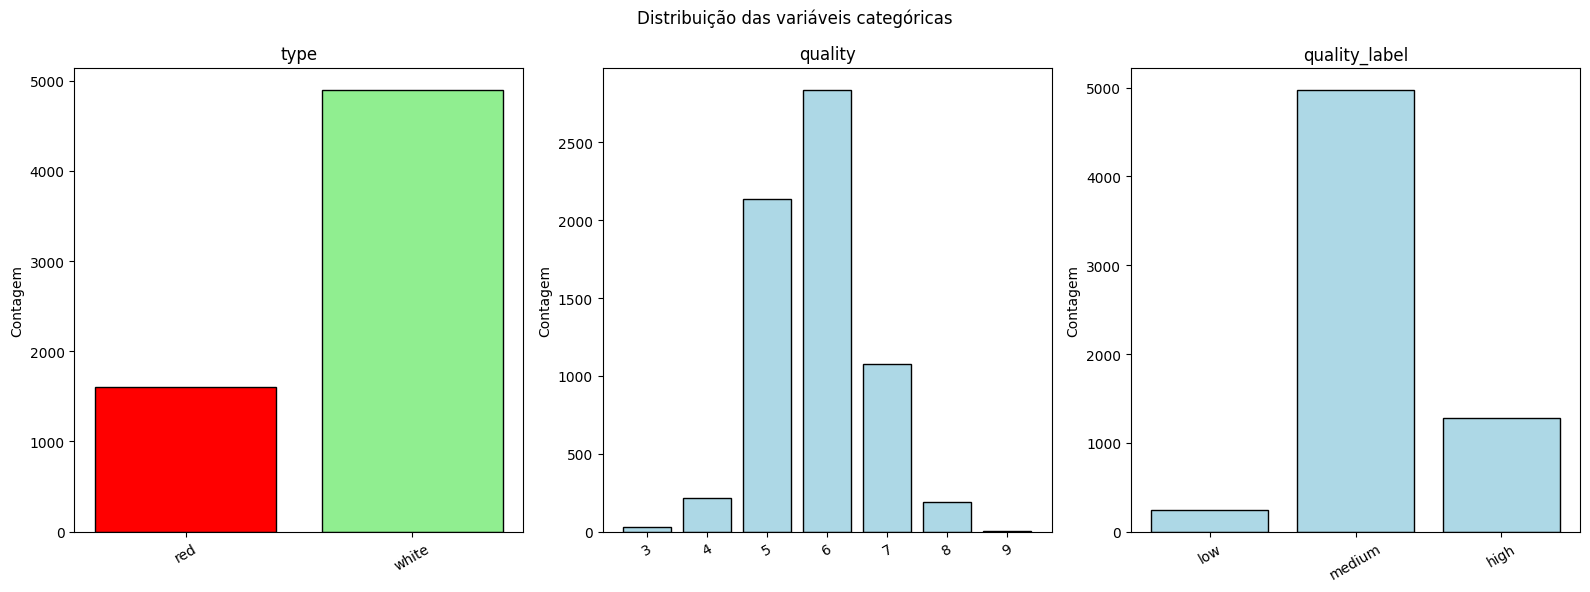

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, col in zip(axes, categorias):
    counts = adega[col].value_counts().sort_index()
    bar_colors = ['red', 'lightgreen'] if col == 'type' else 'lightblue'
    ax.bar(counts.index.astype(str), counts.values, color=bar_colors, edgecolor='black')
    ax.set_title(col)
    ax.set_ylabel('Contagem')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribuição das variáveis categóricas')
plt.tight_layout()
plt.show()

## Questão 3
**Distribuição das variáveis numéricas**

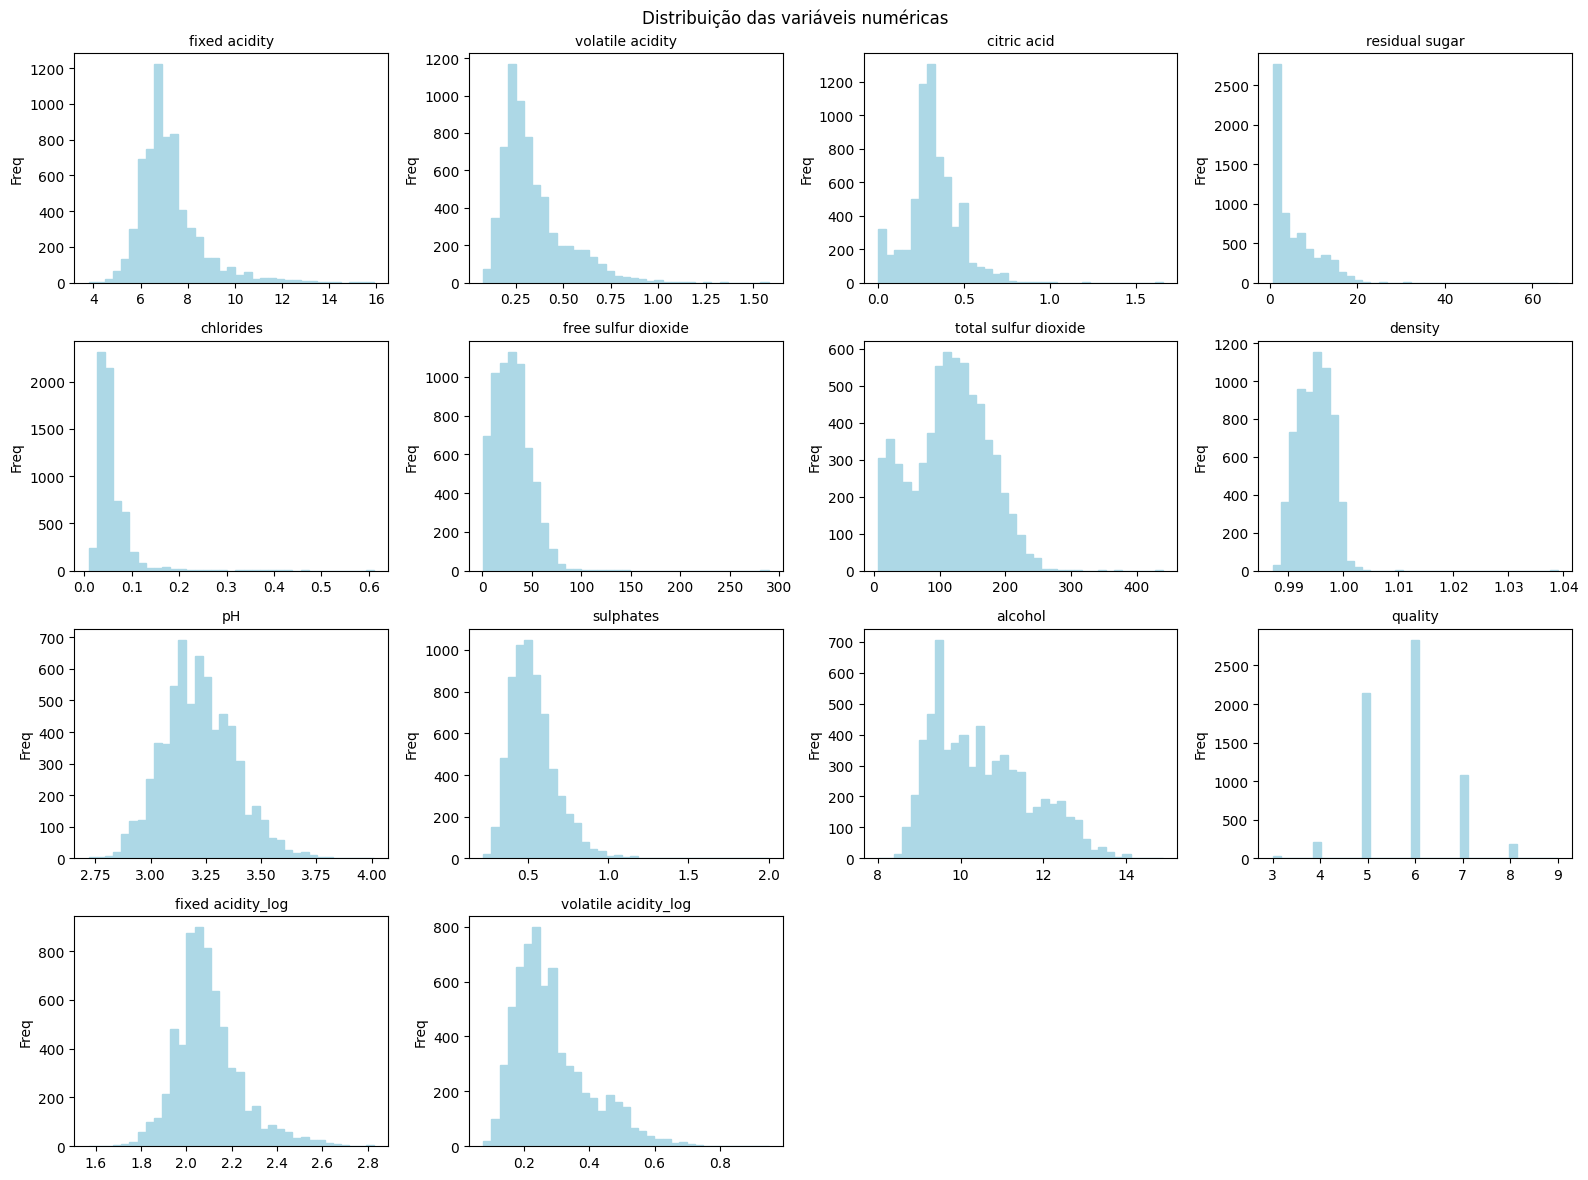

In [44]:
num_cols = adega.select_dtypes(include='number').columns.tolist()

cols_grid = 4
rows_grid = (len(num_cols) + cols_grid - 1) // cols_grid

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, rows_grid * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(adega[col].dropna(), bins=35, color='lightblue', edgecolor='lightblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Freq')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das variáveis numéricas')
plt.tight_layout()
plt.show()

## Questão 4
**Estatísticas descritivas das variáveis numéricas**

Tendência central, dispersão e assimetria

In [11]:
num_cols = adega.select_dtypes(include='number').columns.tolist()

desc = pd.DataFrame({
    'media':     adega[num_cols].mean(),
    'mediana':   adega[num_cols].median(),
    'moda':     adega[num_cols].mode().iloc[0],
    'desvio padrao':      adega[num_cols].std(),
    'variância': adega[num_cols].var(),
    'amplitude':    adega[num_cols].max() - adega[num_cols].min(),
    'interquartilica':      adega[num_cols].quantile(0.75) - adega[num_cols].quantile(0.25),
    'assimetria': adega[num_cols].skew()
})

print(desc.round(2).to_string())

                       media  mediana    moda  desvio padrao  variância  amplitude  interquartilica  assimetria
fixed acidity           7.22     7.00    6.80           1.30       1.68      12.10             1.30        1.72
volatile acidity        0.34     0.29    0.28           0.16       0.03       1.50             0.17        1.50
citric acid             0.32     0.31    0.30           0.15       0.02       1.66             0.14        0.47
residual sugar          5.44     3.00    2.00           4.76      22.64      65.20             6.30        1.44
chlorides               0.06     0.05    0.04           0.04       0.00       0.60             0.03        5.40
free sulfur dioxide    30.53    29.00   29.00          17.75     315.04     288.00            24.00        1.22
total sulfur dioxide  115.74   118.00  111.00          56.52    3194.72     434.00            79.00       -0.00
density                 0.99     0.99    1.00           0.00       0.00       0.05             0.00     

## Questão 5
**Transformação logarítmica**

Variáveis com |assimetria| > 1 são candidatas à transformação log.

Caso contrário (mean=0, std=1).

Variáveis com |assimetria| > 1: ['fixed acidity', 'volatile acidity', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'sulphates', 'volatile acidity_log']


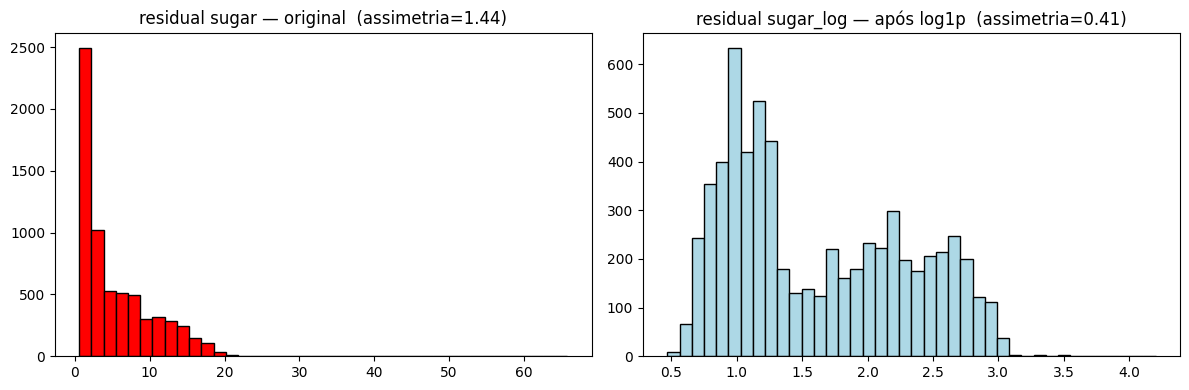

Coluna "residual sugar_log" adicionada ao dataframe.


In [46]:
num_cols = adega.select_dtypes(include='number').columns.tolist()
assimetria = adega[num_cols].skew()

colunas_assimetricas = assimetria[assimetria.abs() > 1].index.tolist()
print('Variáveis com |assimetria| > 1:', colunas_assimetricas)

if colunas_assimetricas:
    col = colunas_assimetricas[2]
    adega[col + '_log'] = np.log1p(adega[col])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(adega[col].dropna(), bins=40, color='red', edgecolor='black')
    axes[0].set_title(f'{col} — original  (assimetria={assimetria[col]:.2f})')
    axes[1].hist(adega[col + '_log'].dropna(), bins=40, color='lightblue', edgecolor='black')
    axes[1].set_title(f'{col}_log — após log1p  (assimetria={adega[col+"_log"].skew():.2f})')
    plt.tight_layout()
    plt.show()
    print(f'Coluna "{col}_log" adicionada ao dataframe.')
else:
    col = 'alcohol'
    adega[col + '_std'] = (adega[col] - adega[col].mean()) / adega[col].std()
    print(f'Sem variáveis muito assimétricas. Estandardização de "{col}":')
    print(f'  mean={adega[col+"_std"].mean():.4f}  std={adega[col+"_std"].std():.4f}')

## Questão 6
**Binning: variável contínua -> categórica**

Variável escolhida: `alcohol`

alcohol_level
baixo (<10%)      2832
médio (10-12%)    2813
alto (>12%)        852
Name: count, dtype: int64


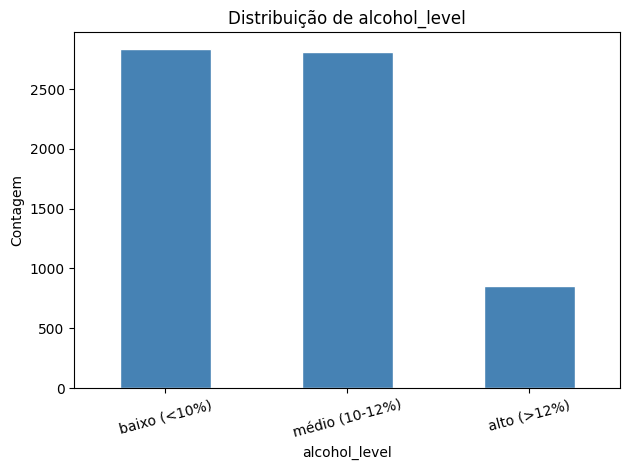

In [17]:
adega['alcohol_level'] = pd.cut(
    adega['alcohol'],
    bins=[0, 10, 12, 15],
    labels=['baixo (<10%)', 'médio (10-12%)', 'alto (>12%)']
)

print(adega['alcohol_level'].value_counts().sort_index())

adega['alcohol_level'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='white'
)
plt.title('Distribuição de alcohol_level')
plt.ylabel('Contagem')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Questão 7
**Encoding de variáveis categóricas**

- Nominal: `color` -> One-Hot Encoding

- Ordinal: `quality_label` -> Label Encoding (low=0, medium=1, high=2)

In [48]:
# One-Hot Encoding — variável nominal 'type'
type_dummies = pd.get_dummies(adega['type'], prefix='type')
adega = pd.concat([adega, type_dummies], axis=1)

# Label Encoding — variável ordinal 'quality_label'
ordinal_map = {'low': 0, 'medium': 1, 'high': 2}
adega['quality_label_enc'] = adega['quality_label'].map(ordinal_map)

print(adega[['type', 'type_red','type_white', 'quality_label', 'quality_label_enc']].head(10).to_string(index=False))

type  type_red  type_red  type_red  type_white  type_white  type_white quality_label quality_label_enc
 red      True      True      True       False       False       False        medium                 1
 red      True      True      True       False       False       False        medium                 1
 red      True      True      True       False       False       False        medium                 1
 red      True      True      True       False       False       False        medium                 1
 red      True      True      True       False       False       False        medium                 1
 red      True      True      True       False       False       False        medium                 1
 red      True      True      True       False       False       False        medium                 1
 red      True      True      True       False       False       False          high                 2
 red      True      True      True       False       False       False   

## Questão 8
**Detecção de outliers**

Método: IQR — valores fora de [Q1 − 1.5×IQR, Q3 + 1.5×IQR]

            variavel  n_outliers  pct (%)
         citric acid         509     7.83
    volatile acidity         377     5.80
       fixed acidity         357     5.49
           chlorides         286     4.40
   fixed acidity_log         285     4.39
             quality         228     3.51
           sulphates         191     2.94
      residual sugar         118     1.82
                  pH          73     1.12
 free sulfur dioxide          62     0.95
total sulfur dioxide          10     0.15
             density           3     0.05
             alcohol           3     0.05


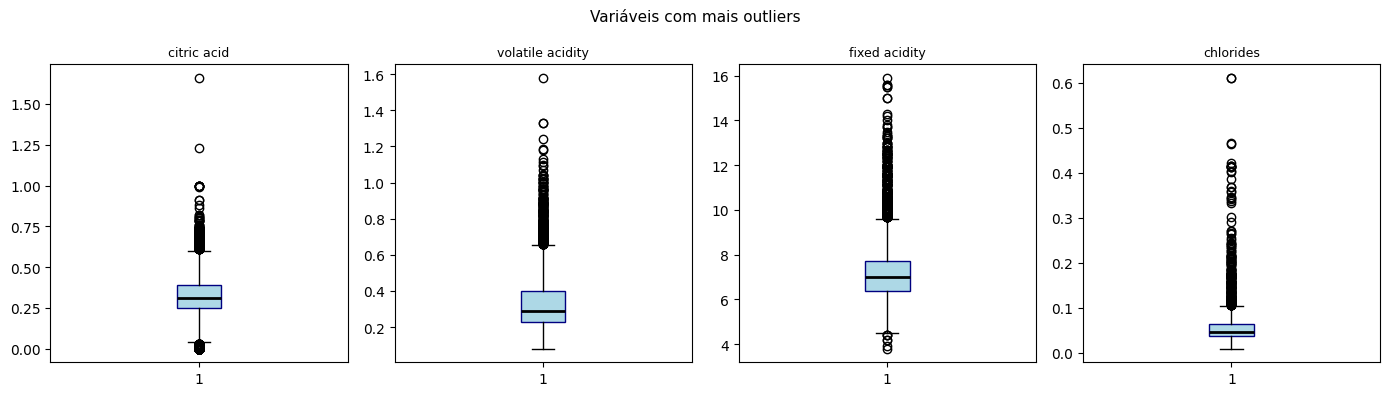

In [9]:
num_cols = adega.select_dtypes(include='number').columns.tolist()

outlier_report = []
for col in num_cols:
    q1, q3 = adega[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((adega[col] < q1 - 1.5 * iqr) | (adega[col] > q3 + 1.5 * iqr)).sum()
    outlier_report.append({
        'variavel': col,
        'n_outliers': n_out,
        'pct (%)': round(n_out / len(adega) * 100, 2)
    })

report_df = pd.DataFrame(outlier_report).sort_values('n_outliers', ascending=False)
print(report_df.to_string(index=False))

# Boxplot das 4 variáveis com mais outliers
top4 = report_df.head(4)['variavel'].tolist()
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, top4):
    ax.boxplot(adega[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontsize=9)
plt.suptitle('Variáveis com mais outliers', fontsize=11)
plt.tight_layout()
plt.show()

## Questão 9
**Teste de hipótese e intervalo de confiança**

Hipótese: a média de `alcohol` é igual a 10.5%

Teste t de uma amostra (x = 0.05)

In [51]:
col   = 'alcohol'
mhip   = 10.5
alpha = 0.05

sample = adega[col].dropna()
t_stat, p_value = stats.ttest_1samp(sample, mhip) # t = (média amostral - mhip) / (desvio-padrão / sqrt(n))

ic = stats.t.interval(
    1 - alpha, # nivel de confiança
    df=len(sample) - 1, # graus de liberdade
    loc=sample.mean(), # media amostral
    scale=stats.sem(sample) # margem de erro
)

print(f'Hipótese nula : média(alcohol) = {mhip}')
print(f'Média amostral: {sample.mean():.4f}')
print(f't-statistic   : {t_stat:.4f}')
print(f'p-value       : {p_value:.6f}')
print(f'IC 95%        : [{ic[0]:.4f}, {ic[1]:.4f}]')
print()
if p_value < alpha:
    print(f'Rejeita a hipótese nula (p={p_value:.4f} < {alpha}) — a média é significativamente diferente de {mhip}')
else:
    print(f'Não rejeita a hipótese nula (p={p_value:.4f} >= {alpha})')

Hipótese nula : média(alcohol) = 10.5
Média amostral: 10.4918
t-statistic   : -0.5541
p-value       : 0.579527
IC 95%        : [10.4628, 10.5208]

Não rejeita a hipótese nula (p=0.5795 >= 0.05)
